# Credit Risk: Feature Engineering


**Author:** Sunmi  
**Goal:** Transform raw features into a richer, model-ready dataset that gives our
machine learning models the best possible signal for predicting Loan Default


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 12})

## 1. Load Dataset/Dataset Overview

In [3]:
# Load
raw = pd.read_csv(r"c:\Users\HP USER\Desktop\Credit Risk Full Project\Credit_Risk_Dataset_Cleaned.csv")
df  = raw.copy()  # working on a copy

print(f' Loaded  →  {df.shape[0]:,} rows  |  {df.shape[1]} columns')
print('\nColumn dtypes:')
print(df.dtypes)

 Loaded  →  32,416 rows  |  12 columns

Column dtypes:
Age                       int64
Income                    int64
Home_Ownership           object
Employment_Years          int64
Loan_Purpose             object
Loan_Risk_Grade          object
Loan_Amount               int64
Interest_Rate           float64
Loan_Default_Status       int64
Loan_Income_Ratio       float64
Previous_Default         object
Credit_History_Years      int64
dtype: object


##  2. Fix Outliers: Cap Impossible Age Values


In [4]:
# Rows affected
print(f'Rows with Age > 80: {(df["Age"] > 80).sum()}')
print('Affected rows:')
display(df[df['Age'] > 80][['Age', 'Income', 'Loan_Default_Status']])

# Cap at 80
df['Age'] = df['Age'].clip(upper=80)

print(f'\n Age capped at 80  →  New max: {df["Age"].max()}')

Rows with Age > 80: 7
Affected rows:


,Age,Income,Loan_Default_Status
81,144,250000,0
183,144,200000,0
575,123,80004,0
747,123,78000,0
32132,144,6000000,0
32251,94,24000,0
32341,84,94800,0



 Age capped at 80  →  New max: 80


To reduce the influence of extreme values on model performance, outliers were handled through capping.

## 3.  Log Transform Skewed Features

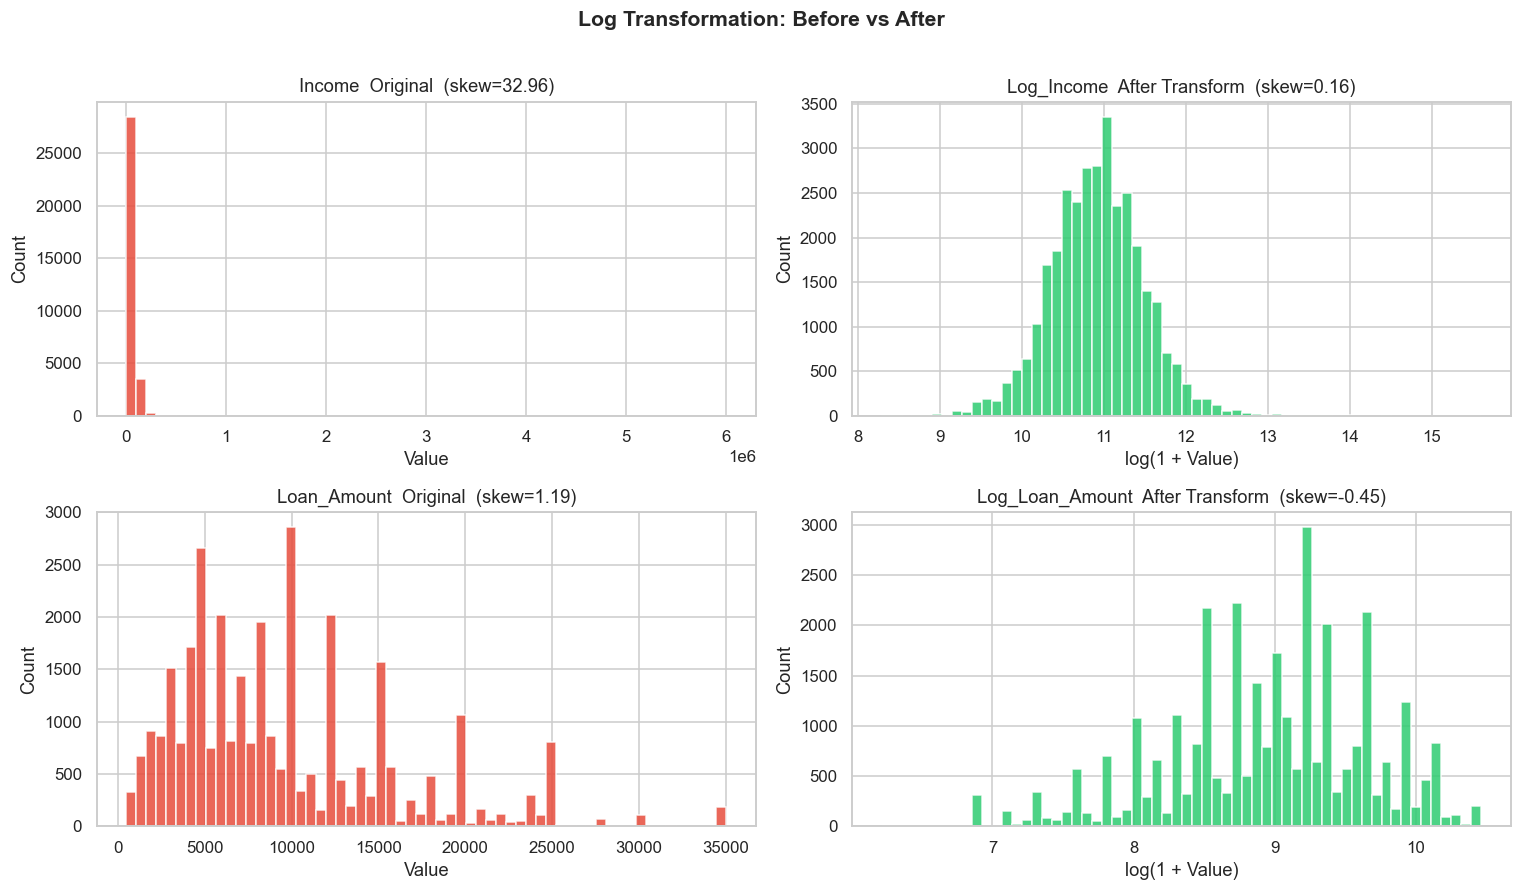

 Log_Income and Log_Loan_Amount columns created.
   Original Income and Loan_Amount columns retained for reference.


In [5]:
skewed_cols = ['Income', 'Loan_Amount']

# Before vs After plots
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for i, col in enumerate(skewed_cols):
    # Before
    axes[i][0].hist(df[col], bins=60, color='#e74c3c', edgecolor='white', alpha=0.85)
    axes[i][0].set_title(f'{col}  Original  (skew={df[col].skew():.2f})')
    axes[i][0].set_xlabel('Value')
    axes[i][0].set_ylabel('Count')

    # Apply transform
    df[f'Log_{col}'] = np.log1p(df[col])

    # After
    axes[i][1].hist(df[f'Log_{col}'], bins=60, color='#2ecc71', edgecolor='white', alpha=0.85)
    axes[i][1].set_title(f'Log_{col}  After Transform  (skew={df[f"Log_{col}"].skew():.2f})')
    axes[i][1].set_xlabel('log(1 + Value)')
    axes[i][1].set_ylabel('Count')

plt.suptitle('Log Transformation: Before vs After', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(' Log_Income and Log_Loan_Amount columns created.')
print('   Original Income and Loan_Amount columns retained for reference.')

##  4. Encode Categorical Features


In [6]:
# ── Label Encoding ────────────────────────────────────────────────────────
grade_order = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6}
df['Grade_Encoded']    = df['Loan_Risk_Grade'].map(grade_order)
df['Prev_Default_Enc'] = df['Previous_Default'].map({'No': 0, 'Yes': 1})

print('── Label Encoded Columns ──')
print(df[['Loan_Risk_Grade', 'Grade_Encoded',
          'Previous_Default', 'Prev_Default_Enc']].head(8).to_string())

# ── One-Hot Encoding ──────────────────────────────────────────────────────
df = pd.get_dummies(df, columns=['Home_Ownership', 'Loan_Purpose'], drop_first=True)

# Show new OHE columns
ohe_cols = [c for c in df.columns if c.startswith('Home_') or c.startswith('Loan_Purpose')]
print(f'\n── New One-Hot Encoded Columns ({len(ohe_cols)}) ──')
print(ohe_cols)
display(df[ohe_cols].head(5))

print(f'\n Encoding complete. DataFrame now has {df.shape[1]} columns.')

── Label Encoded Columns ──
  Loan_Risk_Grade  Grade_Encoded Previous_Default  Prev_Default_Enc
0               D              3              Yes                 1
1               B              1               No                 0
2               C              2               No                 0
3               C              2               No                 0
4               C              2              Yes                 1
5               A              0               No                 0
6               B              1               No                 0
7               B              1               No                 0

── New One-Hot Encoded Columns (8) ──
['Home_Ownership_OTHER', 'Home_Ownership_OWN', 'Home_Ownership_RENT', 'Loan_Purpose_EDUCATION', 'Loan_Purpose_HOME IMPROVEMENT', 'Loan_Purpose_MEDICAL', 'Loan_Purpose_PERSONAL', 'Loan_Purpose_VENTURE']


,Home_Ownership_OTHER,Home_Ownership_OWN,Home_Ownership_RENT,Loan_Purpose_EDUCATION,Loan_Purpose_HOME IMPROVEMENT,Loan_Purpose_MEDICAL,Loan_Purpose_PERSONAL,Loan_Purpose_VENTURE
0,False,False,True,False,False,False,True,False
1,False,True,False,True,False,False,False,False
2,False,False,False,False,False,True,False,False
3,False,False,True,False,False,True,False,False
4,False,False,True,False,False,True,False,False



 Encoding complete. DataFrame now has 22 columns.


## 5. Create New Features


In [7]:
# ── New numerical features ─────────────────────────────────────────────────
df['Loan_Per_Employment_Year'] = df['Loan_Amount'] / (df['Employment_Years'] + 1)
df['Income_Per_Credit_Year']   = df['Income']      / (df['Credit_History_Years'] + 1)

# ── High risk binary flag ──────────────────────────────────────────────────
# Grade D and above (encoded >= 3) AND previously defaulted
df['High_Risk_Flag'] = ((df['Grade_Encoded'] >= 3) & (df['Prev_Default_Enc'] == 1)).astype(int)

print(f'High_Risk_Flag distribution:')
print(df['High_Risk_Flag'].value_counts())
print(f'  Default rate in High_Risk_Flag=1: '
      f"{df[df['High_Risk_Flag']==1]['Loan_Default_Status'].mean()*100:.1f}%")
print(f'  Default rate in High_Risk_Flag=0: '
      f"{df[df['High_Risk_Flag']==0]['Loan_Default_Status'].mean()*100:.1f}%")

# ── Age group ──────────────────────────────────────────────────────────────
df['Age_Group'] = pd.cut(df['Age'],
                          bins=[0, 25, 45, 80],
                          labels=[0, 1, 2])  # 0=Young, 1=Middle, 2=Senior
df['Age_Group'] = df['Age_Group'].astype(int)

print('\nAge_Group distribution:')
print(df['Age_Group'].value_counts().sort_index()
      .rename({0:'Young (≤25)', 1:'Middle (26-45)', 2:'Senior (46+)'}))

# ── Show new columns ───────────────────────────────────────────────────────
new_cols = ['Loan_Per_Employment_Year', 'Income_Per_Credit_Year',
            'High_Risk_Flag', 'Age_Group']
print('\n── New Feature Sample ──')
display(df[new_cols].describe().round(2))

print('\n 4 new features created.')

High_Risk_Flag distribution:
High_Risk_Flag
0    29931
1     2485
Name: count, dtype: int64
  Default rate in High_Risk_Flag=1: 61.6%
  Default rate in High_Risk_Flag=0: 18.6%



Age_Group distribution:
Age_Group
Young (≤25)       15245
Middle (26-45)    16520
Senior (46+)        651
Name: count, dtype: int64

── New Feature Sample ──


,Loan_Per_Employment_Year,Income_Per_Credit_Year,High_Risk_Flag,Age_Group
count,32416.00,32416.00,32416.00,32416.00
mean,2846.20,12163.10,0.08,0.55
std,3466.76,9435.22,0.27,0.54
min,45.45,168.55,0.00,0.00
25%,888.89,5891.62,0.00,0.00
50%,1666.67,9985.45,0.00,1.00
75%,3333.33,15800.00,0.00,1.00
max,35000.00,230769.23,1.00,2.00



 4 new features created.


## 6. Cap Extreme Ratio Values


In [8]:
ratio_cols = ['Loan_Income_Ratio', 'Loan_Per_Employment_Year', 'Income_Per_Credit_Year']

for col in ratio_cols:
    p99 = df[col].quantile(0.99)
    before_max = df[col].max()
    df[col] = df[col].clip(upper=p99)
    print(f'{col:<35}  max before: {before_max:>12.2f}  →  capped at p99: {p99:.2f}')

print('\n Ratio columns capped at 99th percentile.')

Loan_Income_Ratio                    max before:         0.83  →  capped at p99: 0.50
Loan_Per_Employment_Year             max before:     35000.00  →  capped at p99: 18000.00
Income_Per_Credit_Year               max before:    230769.23  →  capped at p99: 45000.00

 Ratio columns capped at 99th percentile.


## 7. Post-Engineering Correlation Check

Feature matrix X: 32,416 rows  x  21 features
Target vector  y: 32,416 rows

Final features:
   1. Age
   2. Employment_Years
   3. Interest_Rate
   4. Loan_Income_Ratio
   5. Credit_History_Years
   6. Log_Income
   7. Log_Loan_Amount
   8. Grade_Encoded
   9. Prev_Default_Enc
  10. Home_Ownership_OTHER
  11. Home_Ownership_OWN
  12. Home_Ownership_RENT
  13. Loan_Purpose_EDUCATION
  14. Loan_Purpose_HOME IMPROVEMENT
  15. Loan_Purpose_MEDICAL
  16. Loan_Purpose_PERSONAL
  17. Loan_Purpose_VENTURE
  18. Loan_Per_Employment_Year
  19. Income_Per_Credit_Year
  20. High_Risk_Flag
  21. Age_Group


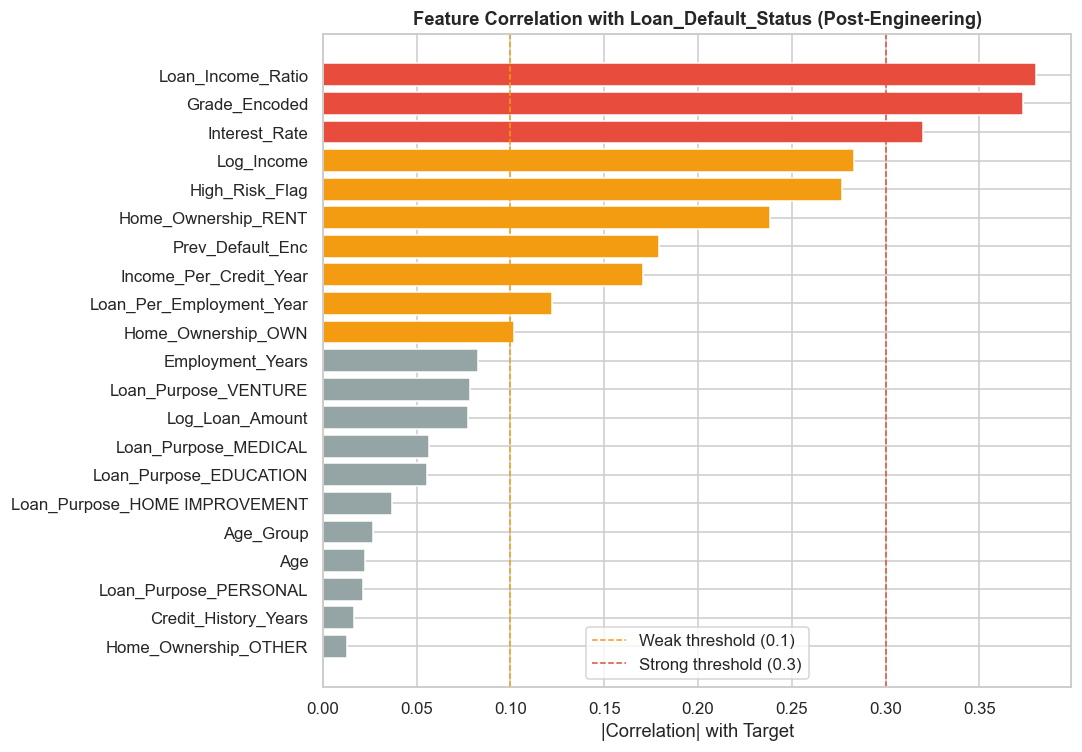


 High correlation pairs (> 0.8):
   Grade_Encoded  ↔  Interest_Rate  =  0.890
   Credit_History_Years  ↔  Age  =  0.874


In [9]:
# ── Define final model features ────────────────────────────────────────────
# Drop original columns that have been replaced or are not needed for modelling
drop_cols = ['Income',        # replaced by Log_Income
             'Loan_Amount',   # replaced by Log_Loan_Amount
             'Loan_Risk_Grade',  # replaced by Grade_Encoded
             'Previous_Default'] # replaced by Prev_Default_Enc

model_df = df.drop(columns=drop_cols)

# Separate features and target
X = model_df.drop(columns=['Loan_Default_Status'])
y = model_df['Loan_Default_Status']

print(f'Feature matrix X: {X.shape[0]:,} rows  x  {X.shape[1]} features')
print(f'Target vector  y: {y.shape[0]:,} rows')
print('\nFinal features:')
for i, col in enumerate(X.columns, 1):
    print(f'  {i:>2}. {col}')

# ── Correlation with target ────────────────────────────────────────────────
target_corr = X.corrwith(y).abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#e74c3c' if v > 0.3 else '#f39c12' if v > 0.1 else '#95a5a6'
          for v in target_corr.values]
ax.barh(target_corr.index[::-1], target_corr.values[::-1],
        color=colors[::-1], edgecolor='white')
ax.axvline(0.1, color='#f39c12', linestyle='--', linewidth=1, label='Weak threshold (0.1)')
ax.axvline(0.3, color='#e74c3c', linestyle='--', linewidth=1, label='Strong threshold (0.3)')
ax.set_xlabel('|Correlation| with Target')
ax.set_title('Feature Correlation with Loan_Default_Status (Post-Engineering)',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

# ── Multicollinearity check ────────────────────────────────────────────────
corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = [(col, row, upper.loc[row, col])
                   for col in upper.columns
                   for row in upper.index
                   if pd.notna(upper.loc[row, col]) and upper.loc[row, col] > 0.8]

if high_corr_pairs:
    print('\n High correlation pairs (> 0.8):')
    for a, b, v in sorted(high_corr_pairs, key=lambda x: -x[2]):
        print(f'   {a}  ↔  {b}  =  {v:.3f}')
else:
    print('\n No multicollinearity issues detected (no pair > 0.8).')

## 8. Save Engineered Dataset


In [10]:
# ── Combine X and y for saving ─────────────────────────────────────────────
final_df = X.copy()
final_df['Loan_Default_Status'] = y

# ── Summary before saving ──────────────────────────────────────────────────
print('── Final Engineered Dataset Summary ──')
print(f'  Shape             : {final_df.shape[0]:,} rows  x  {final_df.shape[1]} columns')
print(f'  Features          : {final_df.shape[1] - 1}')
print(f'  Target column     : Loan_Default_Status')
print(f'  Missing values    : {final_df.isnull().sum().sum()}')
print(f'  Default rate      : {final_df["Loan_Default_Status"].mean()*100:.1f}%')

print('\nColumn data types:')
print(final_df.dtypes)

print('\nSample (first 3 rows):')
display(final_df.head(3))

# ── Save ───────────────────────────────────────────────────────────────────
final_df.to_csv('Credit_Risk_Features.csv', index=False)
print('\n Saved → Credit_Risk_Features.csv')

── Final Engineered Dataset Summary ──
  Shape             : 32,416 rows  x  22 columns
  Features          : 21
  Target column     : Loan_Default_Status
  Missing values    : 0
  Default rate      : 21.9%

Column data types:
Age                                int64
Employment_Years                   int64
Interest_Rate                    float64
Loan_Income_Ratio                float64
Credit_History_Years               int64
Log_Income                       float64
Log_Loan_Amount                  float64
Grade_Encoded                      int64
Prev_Default_Enc                   int64
Home_Ownership_OTHER                bool
Home_Ownership_OWN                  bool
Home_Ownership_RENT                 bool
Loan_Purpose_EDUCATION              bool
Loan_Purpose_HOME IMPROVEMENT       bool
Loan_Purpose_MEDICAL                bool
Loan_Purpose_PERSONAL               bool
Loan_Purpose_VENTURE                bool
Loan_Per_Employment_Year         float64
Income_Per_Credit_Year           fl

,Age,Employment_Years,Interest_Rate,Loan_Income_Ratio,Credit_History_Years,Log_Income,Log_Loan_Amount,Grade_Encoded,Prev_Default_Enc,Home_Ownership_OTHER,...,Loan_Purpose_EDUCATION,Loan_Purpose_HOME IMPROVEMENT,Loan_Purpose_MEDICAL,Loan_Purpose_PERSONAL,Loan_Purpose_VENTURE,Loan_Per_Employment_Year,Income_Per_Credit_Year,High_Risk_Flag,Age_Group,Loan_Default_Status
0,22,123,16.02,0.5,3,10.985310,10.463132,3,1,False,...,False,False,False,True,False,282.258065,14750.0,1,0,1
1,21,5,11.14,0.1,2,9.169623,6.908755,1,0,False,...,True,False,False,False,False,166.666667,3200.0,0,0,0
2,25,1,12.87,0.5,3,9.169623,8.612685,2,0,False,...,False,False,True,False,False,2750.000000,2400.0,0,0,1



 Saved → Credit_Risk_Features.csv


---
##  Feature Engineering Summary

Here is a complete record of every transformation applied in this notebook:

| Transformation | Columns Affected | Why |
|---------------|-----------------|-----|
| **Age capping** | `Age` → capped at 80 | Remove impossible values (max was 144) |
| **Log transform** | `Income` → `Log_Income` | Skewness of 33 — compresses extreme tail |
| **Log transform** | `Loan_Amount` → `Log_Loan_Amount` | Right-skewed — normalises distribution |
| **Label encoding** | `Loan_Risk_Grade` → `Grade_Encoded` (0–6) | Preserves ordinal relationship A→G |
| **Label encoding** | `Previous_Default` → `Prev_Default_Enc` (0/1) | Binary variable |
| **One-hot encoding** | `Home_Ownership` → 3 binary columns | Nominal — no order |
| **One-hot encoding** | `Loan_Purpose` → 5 binary columns | Nominal — no order |
| **New feature** | `Loan_Per_Employment_Year` | Debt burden relative to job stability |
| **New feature** | `Income_Per_Credit_Year` | Earning power relative to credit experience |
| **New feature** | `High_Risk_Flag` (0/1) | Combined Grade ≥ D + Previous Default |
| **New feature** | `Age_Group` (0/1/2) | Captures non-linear age effect |
| **Percentile capping** | Ratio columns at p99 | Prevents extreme outliers from dominating |

---

>  **Feature Engineering complete.**  
> Next step → Open **`Credit_Risk_Modelling.ipynb`** to train and evaluate all four models.